In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
import pickle

In [2]:
df = pd.read_csv("clean_telco_churn.csv")

In [3]:
df.head()

,customerid,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason
0,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,Female,No,No,Yes,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerid         7032 non-null   str    
 1   gender             7032 non-null   str    
 2   senior_citizen     7032 non-null   str    
 3   partner            7032 non-null   str    
 4   dependents         7032 non-null   str    
 5   tenure_months      7032 non-null   int64  
 6   phone_service      7032 non-null   str    
 7   multiple_lines     7032 non-null   str    
 8   internet_service   7032 non-null   str    
 9   online_security    7032 non-null   str    
 10  online_backup      7032 non-null   str    
 11  device_protection  7032 non-null   str    
 12  tech_support       7032 non-null   str    
 13  streaming_tv       7032 non-null   str    
 14  streaming_movies   7032 non-null   str    
 15  contract           7032 non-null   str    
 16  paperless_billing  7032 non-null   

In [5]:
df.describe()

,tenure_months,monthly_charges,total_charges,churn_value,churn_score,cltv
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,0.265785,58.715301,4401.445108
std,24.545260,30.085974,2266.771362,0.441782,21.531321,1182.414266
min,1.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,9.000000,35.587500,401.450000,0.000000,40.000000,3469.750000
50%,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.500000
75%,55.000000,89.862500,3794.737500,1.000000,75.000000,5381.000000
max,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [6]:
df.isnull().sum()

customerid              0
gender                  0
senior_citizen          0
partner                 0
dependents              0
tenure_months           0
phone_service           0
multiple_lines          0
internet_service        0
online_security         0
online_backup           0
device_protection       0
tech_support            0
streaming_tv            0
streaming_movies        0
contract                0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges           0
churn_label             0
churn_value             0
churn_score             0
cltv                    0
churn_reason         5163
dtype: int64

In [7]:
df["total_charges"] = df["total_charges"].replace(" ", np.nan)
df["total_charges"] = df["total_charges"].astype(float)

df["total_charges"].fillna(df["total_charges"].median(), inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_33504\1438485269.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["total_charges"].fillna(df["total_charges"].median(), inplace=True)


0        108.15
1        151.65
2        820.50
3       3046.05
4       5036.30
         ...   
7027    1419.40
7028    1990.50
7029    7362.90
7030     346.45
7031    6844.50
Name: total_charges, Length: 7032, dtype: float64

In [8]:
customer_id = df["customerid"].copy()

In [10]:
columns_to_drop = [
    "churn_value",
    "churn_score",
    "churn_reason",
    "cltv"
]

df = df.drop(columns=columns_to_drop)

In [11]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [12]:
X = df.drop(
    columns=[
        "customerid",
        "churn_label"
    ]
)

y = df["churn_label"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [14]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [15]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [16]:
y_pred = model.predict(X_test)

In [17]:
predicted_churn = model.predict(X)

churn_probability = model.predict_proba(X)[:,1]

In [18]:
predictions_df = df.copy()

predictions_df["Predicted Churn"] = model.predict(X)

predictions_df["Churn Probability"] = model.predict_proba(X)[:,1]

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7633262260127932


In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1033
           1       0.54      0.69      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407



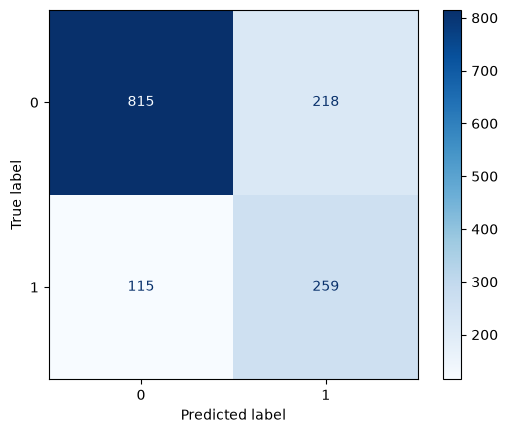

In [21]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.show()

In [22]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
14,contract,0.194953
8,online_security,0.120878
11,tech_support,0.106102
4,tenure_months,0.098505
3,dependents,0.092112
17,monthly_charges,0.084407
18,total_charges,0.079712
9,online_backup,0.046911
7,internet_service,0.031539
2,partner,0.029736


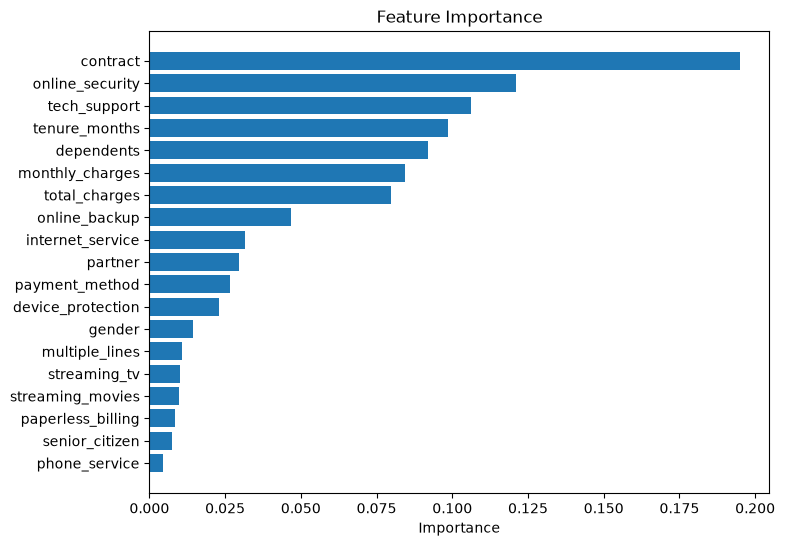

In [23]:
plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Feature Importance")

plt.show()

In [24]:
pickle.dump(
    model,
    open("churn_model.pkl","wb")
)

In [25]:
df["Predicted Churn"] = model.predict(X)

df["Churn Probability"] = model.predict_proba(X)[:,1]

In [26]:
predictions_df.to_csv(
    "customer_churn_predictions.csv",
    index=False
)

In [27]:
predictions_df.head()

,customerid,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,Predicted Churn,Churn Probability
0,2558,1,0,0,0,2,1,0,0,2,...,0,0,0,1,3,53.85,108.15,1,1,0.724458
1,6500,0,0,0,1,2,1,0,1,0,...,0,0,0,1,2,70.70,151.65,1,1,0.733707
2,6540,0,0,0,1,8,1,2,1,0,...,2,2,0,1,2,99.65,820.50,1,1,0.789779
3,5593,0,0,1,1,28,1,2,1,0,...,2,2,0,1,2,104.80,3046.05,1,1,0.554721
4,174,1,0,0,1,49,1,2,1,0,...,2,2,0,1,0,103.70,5036.30,1,1,0.620753
